# Data prep version 1

In [ ]:
import pandas as pd
import torch
from torch_geometric.data import Data
from rdkit import Chem
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm 
import os

CSV_PATH = '../data/raw/smiles_selfies_full.csv'
SMILES_COLUMN = 'smiles' 
SUBSET_FRAC = 0.025
RANDOM_STATE = 42

def smiles_to_graph(smiles):
    """
    Converting Smiles to graph object: Pytorch geometric,
    where nodes will be the atomic number
    and the edges will be the bond type
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None 

    node_features = []
    for atom in mol.GetAtoms():
        node_features.append([atom.GetAtomicNum()])
    x = torch.tensor(node_features, dtype=torch.float)

    edges_list = []
    edge_features = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        
        edges_list.extend([[i, j], [j, i]])
        
        bond_type = bond.GetBondTypeAsDouble()
        edge_features.extend([[bond_type], [bond_type]])

    if not edges_list: # single atom 
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 1), dtype=torch.float)
    else:
        edge_index = torch.tensor(edges_list, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_features, dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, smiles=smiles)

def process_and_split(df, output_dir, prefix=""):
    graphs = []
    for smiles in tqdm(df[SMILES_COLUMN], desc=f"Przetwarzanie {prefix}"):
        graph = smiles_to_graph(smiles)
        if graph is not None:
            graphs.append(graph)
            
    print(f"[{prefix}] Successfully created {len(graphs)} graphs from {len(df)} compounds")

    train_val, test_data = train_test_split(graphs, test_size=0.1, random_state=RANDOM_STATE)
    train_data, val_data = train_test_split(train_val, test_size=0.1111, random_state=RANDOM_STATE) 

    os.makedirs(output_dir, exist_ok=True)
    
    torch.save(train_data, os.path.join(output_dir, 'train.pt'))
    torch.save(val_data, os.path.join(output_dir, 'val.pt'))
    torch.save(test_data, os.path.join(output_dir, 'test.pt'))

df = pd.read_csv(CSV_PATH)
process_and_split(df, output_dir='../data/processed', prefix="FULL DATASET")

df_subset = df.sample(frac=SUBSET_FRAC, random_state=RANDOM_STATE)
process_and_split(df_subset, output_dir='../data/subset', prefix="SUBSET DATASET")

# Data prep version 2

In [ ]:
import pandas as pd
import torch
from torch_geometric.data import Data
from rdkit import Chem
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import os

CSV_PATH = '../data/raw/smiles_selfies_full.csv'
SMILES_COLUMN = 'smiles' 
SUBSET_FRAC = 0.025 # Subset 2.5% 
RANDOM_STATE = 42

SUPPORTED_ATOMS = [1, 6, 7, 8, 9, 15, 16, 17, 35, 53]

def one_hot_encoding(value, choices):
    if value not in choices:
        value = choices[-1]
    return [float(value == choice) for choice in choices]

def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None 

    node_features = []
    for atom in mol.GetAtoms():
        # atom type - 10 length
        atom_type = one_hot_encoding(atom.GetAtomicNum(), SUPPORTED_ATOMS)
        
        # degree of atom - 7 length
        degree = one_hot_encoding(atom.GetDegree(), [0, 1, 2, 3, 4, 5, 6])
        
        # formal charge - 5 length
        charge = one_hot_encoding(atom.GetFormalCharge(), [-1, 0, 1, 2, 'Unknown'])
        
        # hybridization - 6 length
        hybridization = one_hot_encoding(
            str(atom.GetHybridization()), 
            ['SP', 'SP2', 'SP3', 'SP3D', 'SP3D2', 'Unknown']
        )
        
        # aromatic and is ring both 1 length
        is_aromatic = [1.0 if atom.GetIsAromatic() else 0.0]
        is_in_ring = [1.0 if atom.IsInRing() else 0.0]

        # concatenation
        atom_feature_vector = atom_type + degree + charge + hybridization + is_aromatic + is_in_ring
        node_features.append(atom_feature_vector)
        
    x = torch.tensor(node_features, dtype=torch.float)

    edges_list = []
    edge_features = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        
        edges_list.extend([[i, j], [j, i]])
        
        bond_type = bond.GetBondTypeAsDouble()
        edge_features.extend([[bond_type], [bond_type]])

    if not edges_list: 
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 1), dtype=torch.float)
    else:
        edge_index = torch.tensor(edges_list, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_features, dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, smiles=smiles)

def process_and_split(df, output_dir, prefix=""):
    graphs = []
    for smiles in tqdm(df[SMILES_COLUMN], desc=f"Processing {prefix}"):
        graph = smiles_to_graph(smiles)
        if graph is not None:
            graphs.append(graph)
            
    print(f"[{prefix}] Successfully created {len(graphs)} graphs from {len(df)} compounds")

    train_val, test_data = train_test_split(graphs, test_size=0.1, random_state=RANDOM_STATE)
    train_data, val_data = train_test_split(train_val, test_size=0.1111, random_state=RANDOM_STATE) 

    os.makedirs(output_dir, exist_ok=True)
    
    torch.save(train_data, os.path.join(output_dir, 'train.pt'))
    torch.save(val_data, os.path.join(output_dir, 'val.pt'))
    torch.save(test_data, os.path.join(output_dir, 'test.pt'))

df = pd.read_csv(CSV_PATH)
process_and_split(df, output_dir='../data/processed', prefix="FULL DATASET") 
df_subset = df.sample(frac=SUBSET_FRAC, random_state=RANDOM_STATE)
process_and_split(df_subset, output_dir='../data/subset', prefix="SUBSET DATASET")

Processing FULL DATASET:   0%|          | 0/794403 [00:00<?, ?it/s]

[FULL DATASET] Successfully created 794403 graphs from 794403 compounds


Processing SUBSET DATASET:   0%|          | 0/19860 [00:00<?, ?it/s]

[SUBSET DATASET] Successfully created 19860 graphs from 19860 compounds


# Evaluating compounds size to set up good max_nodes parameter

--------------------------------------------------
GRAPH SIZE ANALYSIS REPORT
--------------------------------------------------
Total graphs analyzed: 794403
Min nodes: 5
Max nodes: 37
Mean nodes: 22.44
Median nodes: 22.0
--------------------------------------------------
90% of graphs have <= 32 nodes
95% of graphs have <= 33 nodes
99% of graphs have <= 35 nodes
99.9% of graphs have <= 35 nodes
--------------------------------------------------


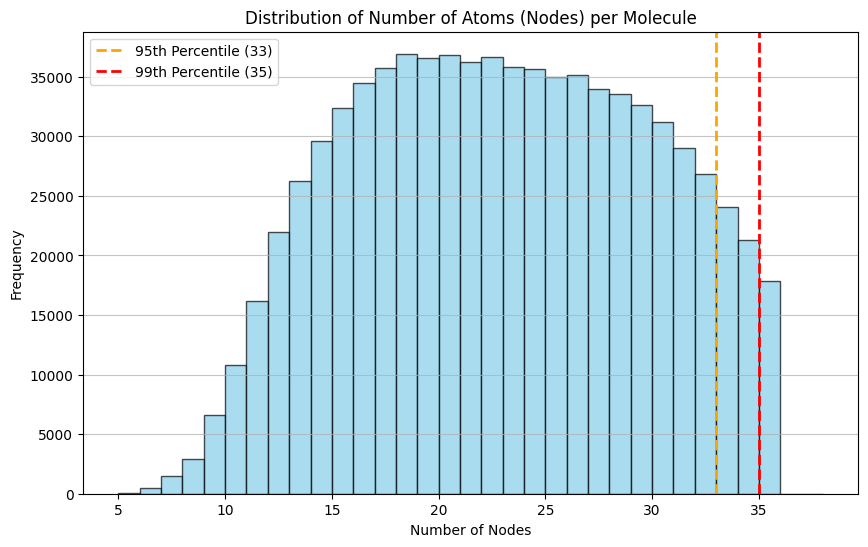

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt

TRAIN_PATH = '../data/processed/train.pt'
VAL_PATH = '../data/processed/val.pt'
TEST_PATH = '../data/processed/test.pt'

def analyze_graph_sizes():    
    train_data = torch.load(TRAIN_PATH, weights_only=False)
    val_data = torch.load(VAL_PATH, weights_only=False)
    test_data = torch.load(TEST_PATH, weights_only=False)
    
    all_graphs = train_data + val_data + test_data
    
    
    node_counts = [graph.num_nodes for graph in all_graphs]
    
    max_nodes = np.max(node_counts)
    min_nodes = np.min(node_counts)
    mean_nodes = np.mean(node_counts)
    median_nodes = np.median(node_counts)
    
    p90 = np.percentile(node_counts, 90)
    p95 = np.percentile(node_counts, 95)
    p99 = np.percentile(node_counts, 99)
    p99_9 = np.percentile(node_counts, 99.9)

    print("-" * 50)
    print("GRAPH SIZE ANALYSIS REPORT")
    print("-" * 50)
    print(f"Total graphs analyzed: {len(node_counts)}")
    print(f"Min nodes: {min_nodes}")
    print(f"Max nodes: {max_nodes}")
    print(f"Mean nodes: {mean_nodes:.2f}")
    print(f"Median nodes: {median_nodes}")
    print("-" * 50)
    print(f"90% of graphs have <= {int(p90)} nodes")
    print(f"95% of graphs have <= {int(p95)} nodes")
    print(f"99% of graphs have <= {int(p99)} nodes")
    print(f"99.9% of graphs have <= {int(p99_9)} nodes")
    print("-" * 50)

    plt.figure(figsize=(10, 6))
    plt.hist(node_counts, bins=range(min_nodes, max_nodes + 2), 
             color='skyblue', edgecolor='black', alpha=0.7)
    
    plt.axvline(p95, color='orange', linestyle='dashed', linewidth=2, label=f'95th Percentile ({int(p95)})')
    plt.axvline(p99, color='red', linestyle='dashed', linewidth=2, label=f'99th Percentile ({int(p99)})')
    
    plt.title('Distribution of Number of Atoms (Nodes) per Molecule')
    plt.xlabel('Number of Nodes')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.show()
    
    return int(p99)


recommended_max_nodes = analyze_graph_sizes()


# Evaluating all unique atoms in dataset

In [2]:
import pandas as pd
from rdkit import Chem
from collections import Counter
from tqdm.notebook import tqdm

CSV_PATH = '../data/raw/smiles_selfies_full.csv'
SMILES_COLUMN = 'smiles'

def analyze_dataset_atoms(csv_path):
    df = pd.read_csv(csv_path)
    
    atom_counts = Counter()
    ptable = Chem.GetPeriodicTable()
    
    invalid_smiles = 0

    for smiles in tqdm(df[SMILES_COLUMN], desc="atom analysis"):
        mol = Chem.MolFromSmiles(smiles)
        
        if mol is None:
            invalid_smiles += 1
            continue
            
        for atom in mol.GetAtoms():
            atomic_num = atom.GetAtomicNum()
            atom_counts[atomic_num] += 1

    print("-" * 50)
    print("atom counts in dataset:")
    print("-" * 50)
    
    if invalid_smiles > 0:
        print(f"rejected {invalid_smiles} wrong smiles.\n")

    supported_atoms = sorted(list(atom_counts.keys()))
    
    print(f"SUPPORTED_ATOMS = {supported_atoms}\n")
    
    print("atom counts:")
    for atomic_num, count in atom_counts.most_common():
        symbol = ptable.GetElementSymbol(atomic_num)
        print(f" - {symbol:<2} (atomic number: {atomic_num:>2}) -> {count:,} occurences")
        
    return supported_atoms

my_supported_atoms = analyze_dataset_atoms(CSV_PATH)

atom analysis:   0%|          | 0/794403 [00:00<?, ?it/s]

--------------------------------------------------
atom counts in dataset:
--------------------------------------------------
SUPPORTED_ATOMS = [1, 6, 7, 8, 9, 15, 16, 17, 35, 53]

atom counts:
 - C  (atomic number:  6) -> 13,182,008 occurences
 - O  (atomic number:  8) -> 1,945,907 occurences
 - N  (atomic number:  7) -> 1,782,284 occurences
 - F  (atomic number:  9) -> 398,556 occurences
 - Cl (atomic number: 17) -> 210,903 occurences
 - S  (atomic number: 16) -> 209,136 occurences
 - Br (atomic number: 35) -> 75,307 occurences
 - I  (atomic number: 53) -> 14,068 occurences
 - P  (atomic number: 15) -> 5,005 occurences
 - H  (atomic number:  1) -> 49 occurences
